# 🎬 Oscar Nominations Analysis — NLP + ChromaDB

This notebook walks through a full pipeline:
1. **Load** Oscar nomination data (from Kaggle CSV or built-in sample)
2. **Embed** nominations using `sentence-transformers`
3. **Store** embeddings in **ChromaDB** (persistent vector store)
4. **Query** with natural language semantic search
5. **Analyse** results with filters, statistics, and visualizations

---
### 📦 Install dependencies (run once)
```bash
pip install chromadb sentence-transformers pandas matplotlib seaborn requests
```

In [2]:
# ── 0. Install dependencies ─────────────────────────────────────────────────
# Uncomment the line below if you haven't installed yet
!pip install chromadb sentence-transformers pandas matplotlib seaborn requests -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [3]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from IPython.display import display, Markdown

import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='muted')

print('✅ All imports successful.')

✅ All imports successful.


---
## 📥 Step 1 — Load Oscar Nomination Data

**Option A (recommended):** Download the dataset from Kaggle:
> [The Oscar Award, 1927–2023](https://www.kaggle.com/datasets/unanimad/the-oscar-award)
> Save `the_oscar_award.csv` in the same folder as this notebook, then set `USE_KAGGLE_CSV = True`.

**Option B:** Use the built-in sample data (no download needed).

In [4]:
from google.colab import files

uploaded_files = files.upload()

Saving the_oscar_award.csv to the_oscar_award.csv


In [5]:
import pandas as pd

file_name = next(iter(uploaded_files)) # Get the name of the uploaded file
df = pd.read_csv(file_name)

print(f'✅ Loaded {len(df)} rows from {file_name}.')
df.head()

✅ Loaded 11110 rows from the_oscar_award.csv.


,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Patent Leather Kid,False
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Last Command,True
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Way of All Flesh,True
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,A Ship Comes In,False


In [6]:
print(df.shape)

(11110, 8)


In [7]:
df.describe()

,year_film,year_ceremony,ceremony
count,11110.000000,11110.000000,11110.000000
mean,1977.183708,1978.183708,50.209271
std,27.679616,27.679616,27.636154
min,1927.000000,1928.000000,1.000000
25%,1953.000000,1954.000000,26.000000
50%,1977.000000,1978.000000,50.000000
75%,2002.000000,2003.000000,75.000000
max,2024.000000,2025.000000,97.000000


In [8]:
df['canon_category'].unique()

array(['ACTOR IN A LEADING ROLE', 'ACTRESS IN A LEADING ROLE',
       'ART DIRECTION', 'CINEMATOGRAPHY', 'DIRECTING (Comedy Picture)',
       'DIRECTING (Dramatic Picture)', 'VISUAL EFFECTS', 'BEST PICTURE',
       'UNIQUE AND ARTISTIC PICTURE', 'WRITING (Adapted Screenplay)',
       'WRITING (Original Story)', 'WRITING (Title Writing)',
       'SPECIAL AWARD', 'DIRECTING', 'SOUND RECORDING',
       'SHORT FILM (Animated)', 'SHORT SUBJECT (Comedy)',
       'SHORT SUBJECT (Novelty)', 'ASSISTANT DIRECTOR', 'FILM EDITING',
       'MUSIC (Original Song Score or Adaptation Score)',
       'MUSIC (Original Song)', 'DANCE DIRECTION',
       'ACTOR IN A SUPPORTING ROLE', 'ACTRESS IN A SUPPORTING ROLE',
       'SHORT SUBJECT (Color)', 'SHORT SUBJECT (One-reel)',
       'SHORT SUBJECT (Two-reel)', 'IRVING G. THALBERG MEMORIAL AWARD',
       'MUSIC (Original Score)', 'CINEMATOGRAPHY (Black-and-White)',
       'CINEMATOGRAPHY (Color)', 'ART DIRECTION (Black-and-White)',
       'ART DIRECTION (Colo

---
## 🔍 Step 2 — EDA: Explore the Data

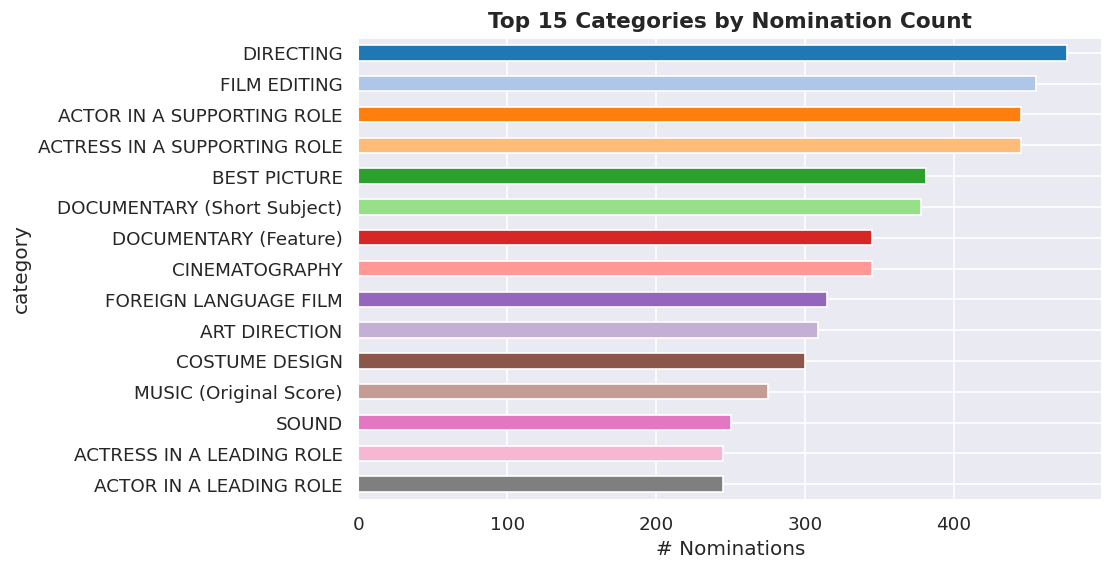

In [9]:
# ── 2a. Nominations per category ─────────────────────────────────────────────
cat_counts = df['category'].value_counts().head(15)

plt.figure(figsize=(8, 5))
cat_counts.plot(kind='barh', color=cm.tab20.colors[:len(cat_counts)])

plt.title('Top 15 Categories by Nomination Count', fontsize=13, fontweight='bold')
plt.xlabel('# Nominations')
plt.gca().invert_yaxis()

plt.show()

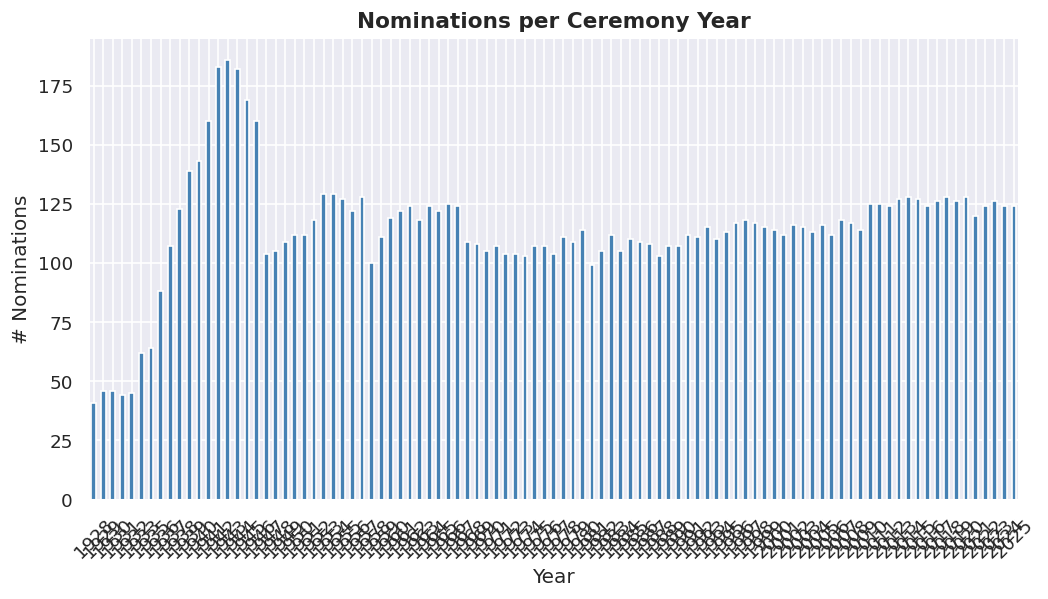

In [10]:
# ── 2b. Nominations per year ─────────────────────────────────────────────────
year_counts = df.groupby('year_ceremony').size()

plt.figure(figsize=(10, 5))
year_counts.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Nominations per Ceremony Year', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('# Nominations')
plt.xticks(rotation=45)

plt.show()

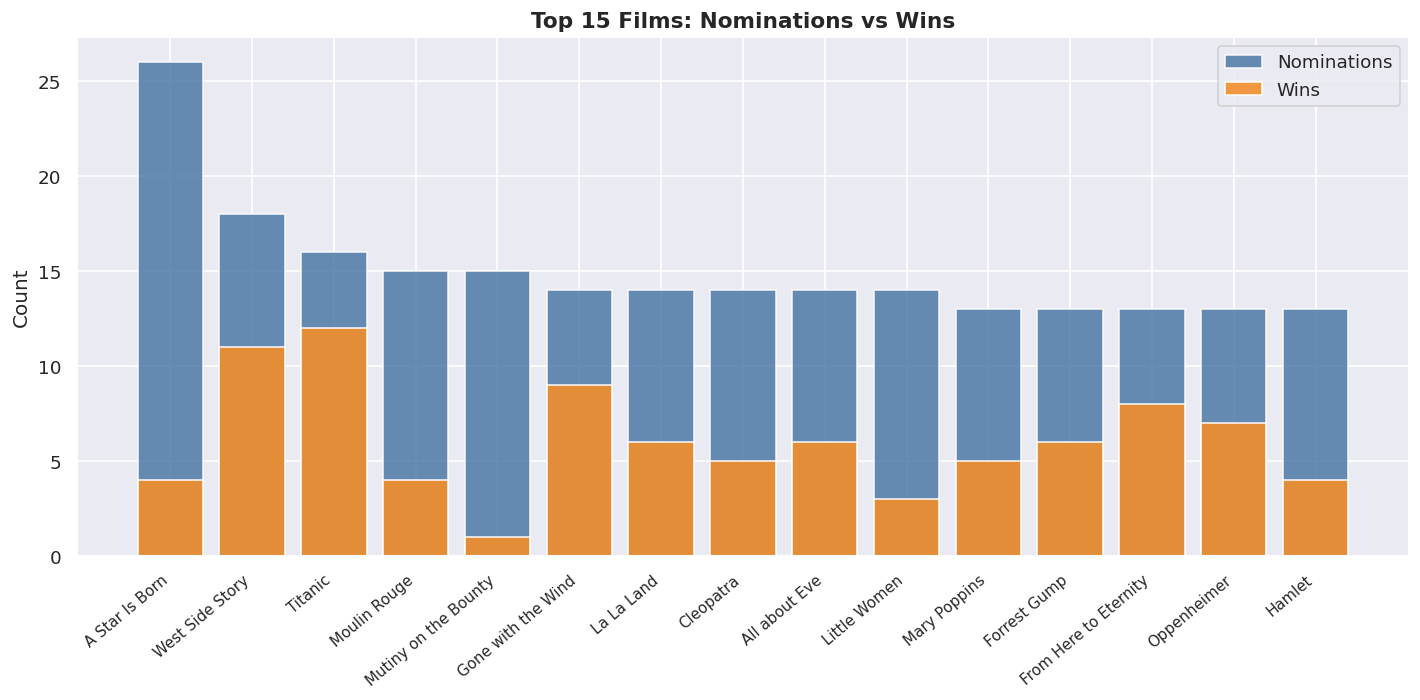

,nominations,wins
film,,
A Star Is Born,26,4
West Side Story,18,11
Titanic,16,12
Moulin Rouge,15,4
Mutiny on the Bounty,15,1
Gone with the Wind,14,9
La La Land,14,6
Cleopatra,14,5
All about Eve,14,6


In [11]:
# ── 2c. Films with most nominations ──────────────────────────────────────────
top_films = df.groupby('film').agg(
    nominations=('film', 'count'),
    wins=('winner', 'sum')
).sort_values('nominations', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top_films))
ax.bar(x, top_films['nominations'], label='Nominations', color='#4e79a7', alpha=0.85)
ax.bar(x, top_films['wins'],        label='Wins',        color='#f28e2b', alpha=0.9)
ax.set_xticks(list(x))
ax.set_xticklabels(top_films.index, rotation=40, ha='right', fontsize=9)
ax.set_title('Top 15 Films: Nominations vs Wins', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

display(top_films)

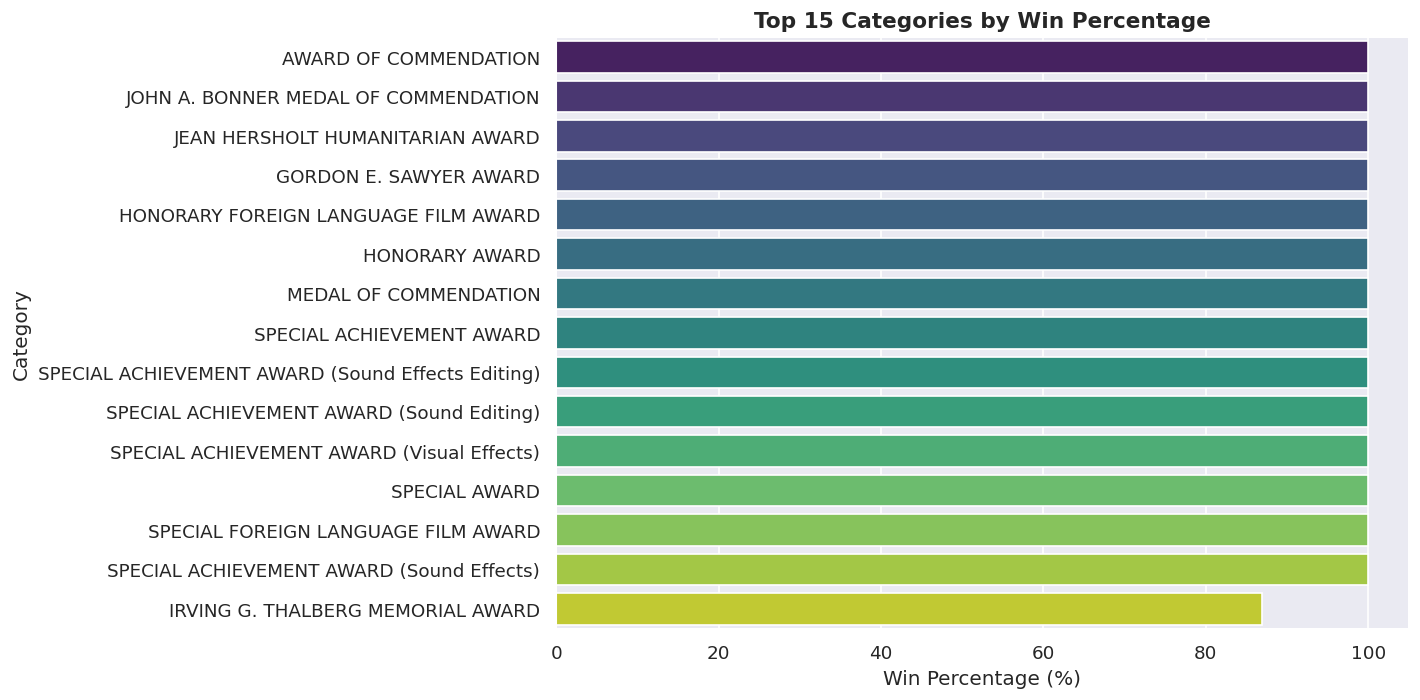

In [12]:
# ── 2d. Win Percentage per Category ──────────────────────────────────────────
category_win_rate = df.groupby('category').agg(
    nominations=('category', 'count'),
    wins=('winner', 'sum')
)
category_win_rate['win_percentage'] = (category_win_rate['wins'] / category_win_rate['nominations']) * 100

top_win_rate_categories = category_win_rate.sort_values('win_percentage', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='win_percentage', y=top_win_rate_categories.index, data=top_win_rate_categories, palette='viridis', ax=ax)
ax.set_title('Top 15 Categories by Win Percentage', fontsize=13, fontweight='bold')
ax.set_xlabel('Win Percentage (%)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

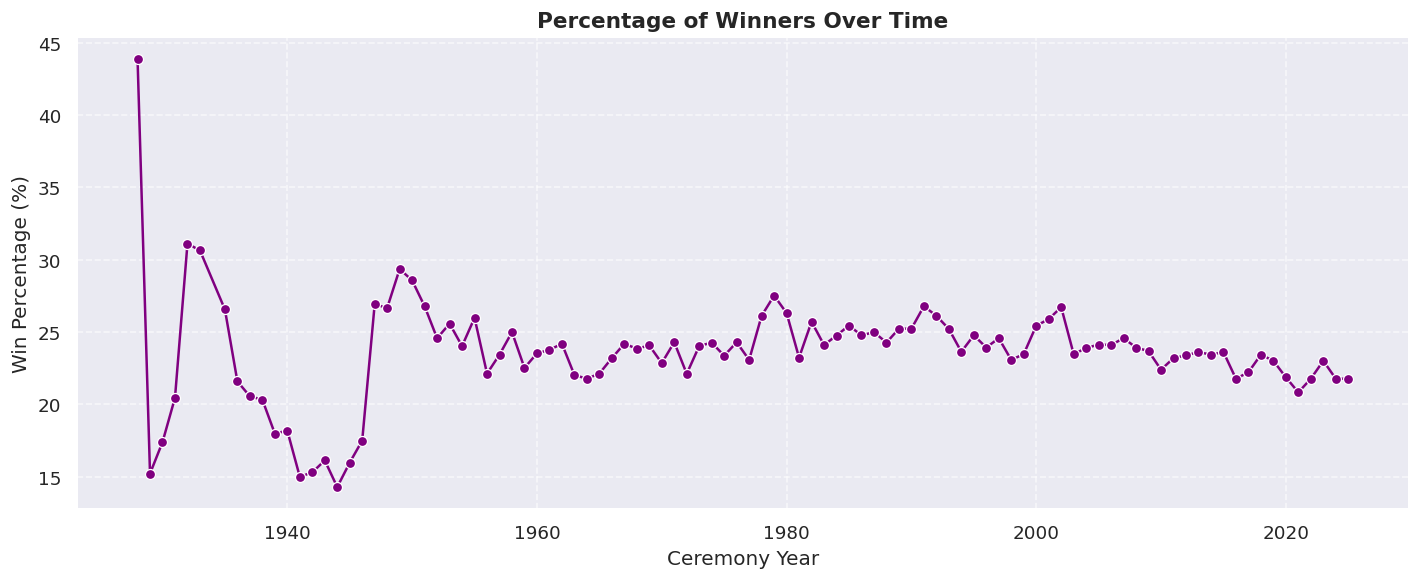

In [13]:
# ── 2e. Percentage of Winners Over Time ──────────────────────────────────────────

yearly_summary = df.groupby('year_ceremony').agg(
    total_nominations=('year_ceremony', 'count'),
    total_winners=('winner', lambda x: (x == True).sum())
).reset_index()
yearly_summary['win_percentage'] = (yearly_summary['total_winners'] / yearly_summary['total_nominations']) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(x='year_ceremony', y='win_percentage', data=yearly_summary, marker='o', color='purple', ax=ax)
ax.set_title('Percentage of Winners Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Ceremony Year')
ax.set_ylabel('Win Percentage (%)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 🧠 Step 3 — NLP: Build Rich Text Documents & Embed

We create a **rich text document** for each nomination by combining all its fields.
Then we embed each document using `sentence-transformers`.

In [14]:
# ── 3a. Build text documents ──────────────────────────────────────────────────
def build_document(row):
    """Create a rich, natural-language sentence for each nomination."""
    status = 'won' if row['winner'] else 'was nominated for'
    return (
        f"{row['name']} {status} the Oscar for {row['category']} "
        f"at the {row['year_ceremony']} Academy Awards for the film '{row['film']}'. "
        f"Category: {row['category']}. Film: {row['film']}. Year: {row['year_ceremony']}."
    )

df['document'] = df.apply(build_document, axis=1)

print('Sample documents:')
for doc in df['document'].head(3):
    print(f'  → {doc}')

Sample documents:
  → Richard Barthelmess was nominated for the Oscar for ACTOR at the 1928 Academy Awards for the film 'The Noose'. Category: ACTOR. Film: The Noose. Year: 1928.
  → Richard Barthelmess was nominated for the Oscar for ACTOR at the 1928 Academy Awards for the film 'The Patent Leather Kid'. Category: ACTOR. Film: The Patent Leather Kid. Year: 1928.
  → Emil Jannings won the Oscar for ACTOR at the 1928 Academy Awards for the film 'The Last Command'. Category: ACTOR. Film: The Last Command. Year: 1928.


In [15]:
# ── 3b. Load sentence-transformer model ──────────────────────────────────────
EMBED_MODEL = 'all-MiniLM-L6-v2' # Recommended model for good balance of speed/performance
BATCH_SIZE  = 64                 # Adjust for your available GPU/CPU memory

print(f'Loading embedding model: {EMBED_MODEL} ...')
model = SentenceTransformer(EMBED_MODEL)
print(f'✅ Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}')

Loading embedding model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded. Embedding dimension: 384


In [16]:
# ── 3c. Generate embeddings ───────────────────────────────────────────────────
print(f'Embedding {len(df)} documents in batches of {BATCH_SIZE}...')
embeddings = model.encode(
    df['document'].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True   # Cosine-ready
)
print(f'✅ Embeddings shape: {embeddings.shape}')

Embedding 11110 documents in batches of 64...


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

✅ Embeddings shape: (11110, 384)


---
## 🗄️ Step 4 — Store in ChromaDB

In [17]:
# ── 4a. Initialise persistent ChromaDB client ─────────────────────────────────
CHROMA_DB_PATH = 'chroma_db' # Where to store ChromaDB data
COLLECTION_NAME = 'oscar_nominations' # Name of our ChromaDB collection

client = chromadb.PersistentClient(path=CHROMA_DB_PATH)

# Delete existing collection if rebuilding
try:
    client.delete_collection(name=COLLECTION_NAME)
    print(f'♻️  Deleted existing collection "{COLLECTION_NAME}"')
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    metadata={'hnsw:space': 'cosine'}  # Use cosine similarity
)
print(f'✅ Created collection: "{COLLECTION_NAME}"')

✅ Created collection: "oscar_nominations"


In [18]:
# ── 4b. Upsert documents + embeddings + metadata ─────────────────────────────
ids        = [f'nom_{i}' for i in df.index]
documents  = df['document'].tolist()
metadatas  = df[['year_ceremony','category','name','film','winner']].to_dict('records')

# Convert bool -> str for ChromaDB metadata
for m in metadatas:
    m['winner'] = str(m['winner'])
    m['year_ceremony'] = int(m['year_ceremony'])

# Insert in batches
CHROMA_BATCH = 500
for start in range(0, len(ids), CHROMA_BATCH):
    end = start + CHROMA_BATCH
    collection.add(
        ids=ids[start:end],
        documents=documents[start:end],
        embeddings=embeddings[start:end].tolist(),
        metadatas=metadatas[start:end],
    )
    print(f'  Inserted rows {start}–{min(end, len(ids))-1}')

print(f'\n✅ ChromaDB now contains {collection.count()} documents.')

  Inserted rows 0–499
  Inserted rows 500–999
  Inserted rows 1000–1499
  Inserted rows 1500–1999
  Inserted rows 2000–2499
  Inserted rows 2500–2999
  Inserted rows 3000–3499
  Inserted rows 3500–3999
  Inserted rows 4000–4499
  Inserted rows 4500–4999
  Inserted rows 5000–5499
  Inserted rows 5500–5999
  Inserted rows 6000–6499
  Inserted rows 6500–6999
  Inserted rows 7000–7499
  Inserted rows 7500–7999
  Inserted rows 8000–8499
  Inserted rows 8500–8999
  Inserted rows 9000–9499
  Inserted rows 9500–9999
  Inserted rows 10000–10499
  Inserted rows 10500–10999
  Inserted rows 11000–11109

✅ ChromaDB now contains 11110 documents.


---
## 🔎 Step 5 — Semantic Search Queries

Ask natural language questions — ChromaDB retrieves the most semantically similar nominations.

In [19]:
# ── Helper: run semantic search ───────────────────────────────────────────────
def semantic_search(query: str,
                    n_results: int = 5,
                    year: int = None,
                    category: str = None,
                    winners_only: bool = False) -> pd.DataFrame:
    """
    Semantic search over Oscar nominations.

    Args:
        query:        Natural-language query string.
        n_results:    Number of results to return.
        year:         Filter to a specific ceremony year.
        category:     Filter to a specific award category.
        winners_only: If True, restrict to winners only.
    Returns:
        DataFrame of top results with similarity scores.
    """
    query_emb = model.encode([query], normalize_embeddings=True).tolist()

    # Build ChromaDB where-clause
    where_clauses = []
    if year:
        where_clauses.append({'year_ceremony': {'$eq': year}})
    if category:
        where_clauses.append({'category': {'$eq': category}})
    if winners_only:
        where_clauses.append({'winner': {'$eq': 'True'}})

    where = None
    if len(where_clauses) == 1:
        where = where_clauses[0]
    elif len(where_clauses) > 1:
        where = {'$and': where_clauses}

    results = collection.query(
        query_embeddings=query_emb,
        n_results=n_results,
        where=where,
        include=['documents', 'metadatas', 'distances']
    )

    rows = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        rows.append({
            'similarity': round(1 - dist, 4),  # cosine distance → similarity
            'year': meta['year_ceremony'],
            'category': meta['category'],
            'name': meta['name'],
            'film': meta['film'],
            'winner': meta['winner'] == 'True',
        })

    return pd.DataFrame(rows)

print('✅ semantic_search() ready.')

✅ semantic_search() ready.


In [20]:
# ── Query 1: General semantic search ─────────────────────────────────────────
query = 'films about family and identity'
results = semantic_search(query, n_results=6)
display(Markdown(f'### 🔍 Query: "{query}"'))
display(results)

### 🔍 Query: "films about family and identity"

,similarity,year,category,name,film,winner
0,0.4915,2019,DOCUMENTARY (Feature),Talal Derki/Ansgar Frerich/Eva Kemme/Tobias N....,Of Fathers and Sons,False
1,0.4709,1988,FOREIGN LANGUAGE FILM,Italy,The Family,False
2,0.4667,1941,SPECIAL EFFECTS,Vernon L. Walker/John O. Aalberg,Swiss Family Robinson,False
3,0.4614,1989,DOCUMENTARY (Short Subject),Lise Yasui/Ann Tegnell,Family Gathering,False
4,0.4294,2003,DOCUMENTARY (Short Subject),Roger Weisberg/Murray Nossel,Why Can't We Be a Family Again?,False
5,0.4251,1967,DOCUMENTARY (Feature),Alex Grasshoff,The Really Big Family,False


In [21]:
# ── Query 2: Filter by year ───────────────────────────────────────────────────
query = 'powerful female performance'
results = semantic_search(query, n_results=5, year=2023)
display(Markdown(f'### 🔍 Query: "{query}" — filtered to 2023'))
display(results)

### 🔍 Query: "powerful female performance" — filtered to 2023

,similarity,year,category,name,film,winner
0,0.2901,2023,ACTRESS IN A LEADING ROLE,Michelle Yeoh,Everything Everywhere All at Once,True
1,0.2875,2023,WRITING (Adapted Screenplay),Sarah Polley,Women Talking,True
2,0.2743,2023,ACTRESS IN A LEADING ROLE,Ana de Armas,Blonde,False
3,0.2722,2023,BEST PICTURE,Dede Gardner/Jeremy Kleiner/Frances McDormand,Women Talking,False
4,0.2704,2023,ACTRESS IN A SUPPORTING ROLE,Stephanie Hsu,Everything Everywhere All at Once,False


In [22]:
# ── Query 3: Winners only ─────────────────────────────────────────────────────
query = 'war drama international film'
results = semantic_search(query, n_results=5, winners_only=True)
display(Markdown(f'### 🔍 Query: "{query}" — winners only'))
display(results)

### 🔍 Query: "war drama international film" — winners only

,similarity,year,category,name,film,winner
0,0.5453,1969,FOREIGN LANGUAGE FILM,Union of Soviet Socialist Republics,War and Peace,True
1,0.5190,1967,DOCUMENTARY (Feature),Peter Watkins,The War Game,True
2,0.5093,1943,DOCUMENTARY,United States Army Special Services,Prelude to War,True
3,0.4803,1954,SPECIAL EFFECTS,Paramount Studio,The War of the Worlds,True
4,0.4689,2004,DOCUMENTARY (Feature),Errol Morris/Michael Williams,The Fog of War,True


In [23]:
# ── Query 4: Filter by category ───────────────────────────────────────────────
query = 'animated film with music'
results = semantic_search(query, n_results=5, category='ANIMATED FEATURE FILM') # Corrected category
display(Markdown(f'### 🔍 Query: "{query}" — category: ANIMATED FEATURE FILM'))
display(results)

### 🔍 Query: "animated film with music" — category: ANIMATED FEATURE FILM

,similarity,year,category,name,film,winner
0,0.4378,2016,ANIMATED FEATURE FILM,Charlie Kaufman/Duke Johnson/Rosa Tran,Anomalisa,False
1,0.4321,2015,ANIMATED FEATURE FILM,Tomm Moore/Paul Young,Song of the Sea,False
2,0.4289,2003,ANIMATED FEATURE FILM,Jeffrey Katzenberg,Spirit: Stallion of the Cimarron,False
3,0.4253,2006,ANIMATED FEATURE FILM,Hayao Miyazaki,Howl's Moving Castle,False
4,0.4194,2013,ANIMATED FEATURE FILM,Tim Burton,Frankenweenie,False


In [24]:
# ── Query 5: Custom query (edit freely!) ──────────────────────────────────────
CUSTOM_QUERY = 'comedic performance in a dark or surreal story'  # ← change me!
results = semantic_search(CUSTOM_QUERY, n_results=8)
display(Markdown(f'### 🔍 Custom Query: "{CUSTOM_QUERY}"'))
display(results)

### 🔍 Custom Query: "comedic performance in a dark or surreal story"

,similarity,year,category,name,film,winner
0,0.4770,1931,WRITING (Original Story),Harry d'Abbadie d'Arrast/Douglas Doty/Donald O...,Laughter,False
1,0.4601,1967,MUSIC (Scoring of Music--adaptation or treatment),Ken Thorne,A Funny Thing Happened on the Way to the Forum,True
2,0.4329,1976,MUSIC (Original Song),Fred Ebb/John Kander,Funny Lady,False
3,0.4232,1947,MUSIC (Music Score of a Dramatic or Comedy Pic...,Franz Waxman,Humoresque,False
4,0.4221,1944,WRITING (Original Motion Picture Story),William Saroyan,The Human Comedy,True
5,0.4056,1944,CINEMATOGRAPHY (Black-and-White),Harry Stradling,The Human Comedy,False
6,0.3992,1997,SOUND EFFECTS EDITING,Bruce Stambler,The Ghost and the Darkness,True
7,0.3883,1945,MUSIC (Scoring of a Musical Picture),Robert Emmett Dolan,Lady in the Dark,False


---
## 📊 Step 6 — Visualise Similarity Scores

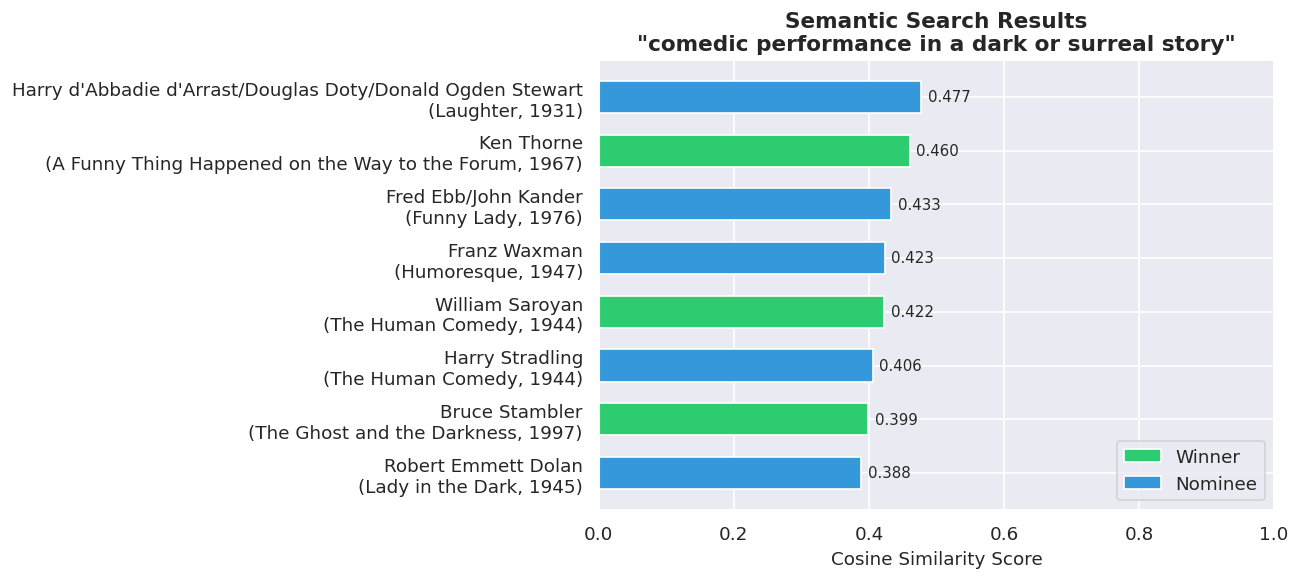

In [25]:
# ── Similarity bar chart for last query ───────────────────────────────────────
results_plot = results.copy()
results_plot['label'] = results_plot['name'] + '\n(' + results_plot['film'] + ', ' + results_plot['year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if w else '#3498db' for w in results_plot['winner']]
bars = ax.barh(results_plot['label'], results_plot['similarity'], color=colors, edgecolor='white', height=0.6)
ax.set_xlim(0, 1)
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title(f'Semantic Search Results\n"{CUSTOM_QUERY}"', fontsize=13, fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Winner'), Patch(facecolor='#3498db', label='Nominee')]
ax.legend(handles=legend_elements, loc='lower right')

for bar, score in zip(bars, results_plot['similarity']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 🗺️ Step 7 — 2D Visualisation of Embedding Space

We reduce the high-dimensional embeddings to 2D using **UMAP** (or **PCA** as fallback) to visualise how nominations cluster.

Using UMAP for 2D projection...
✅ 2D projection complete. Shape: (11110, 2)


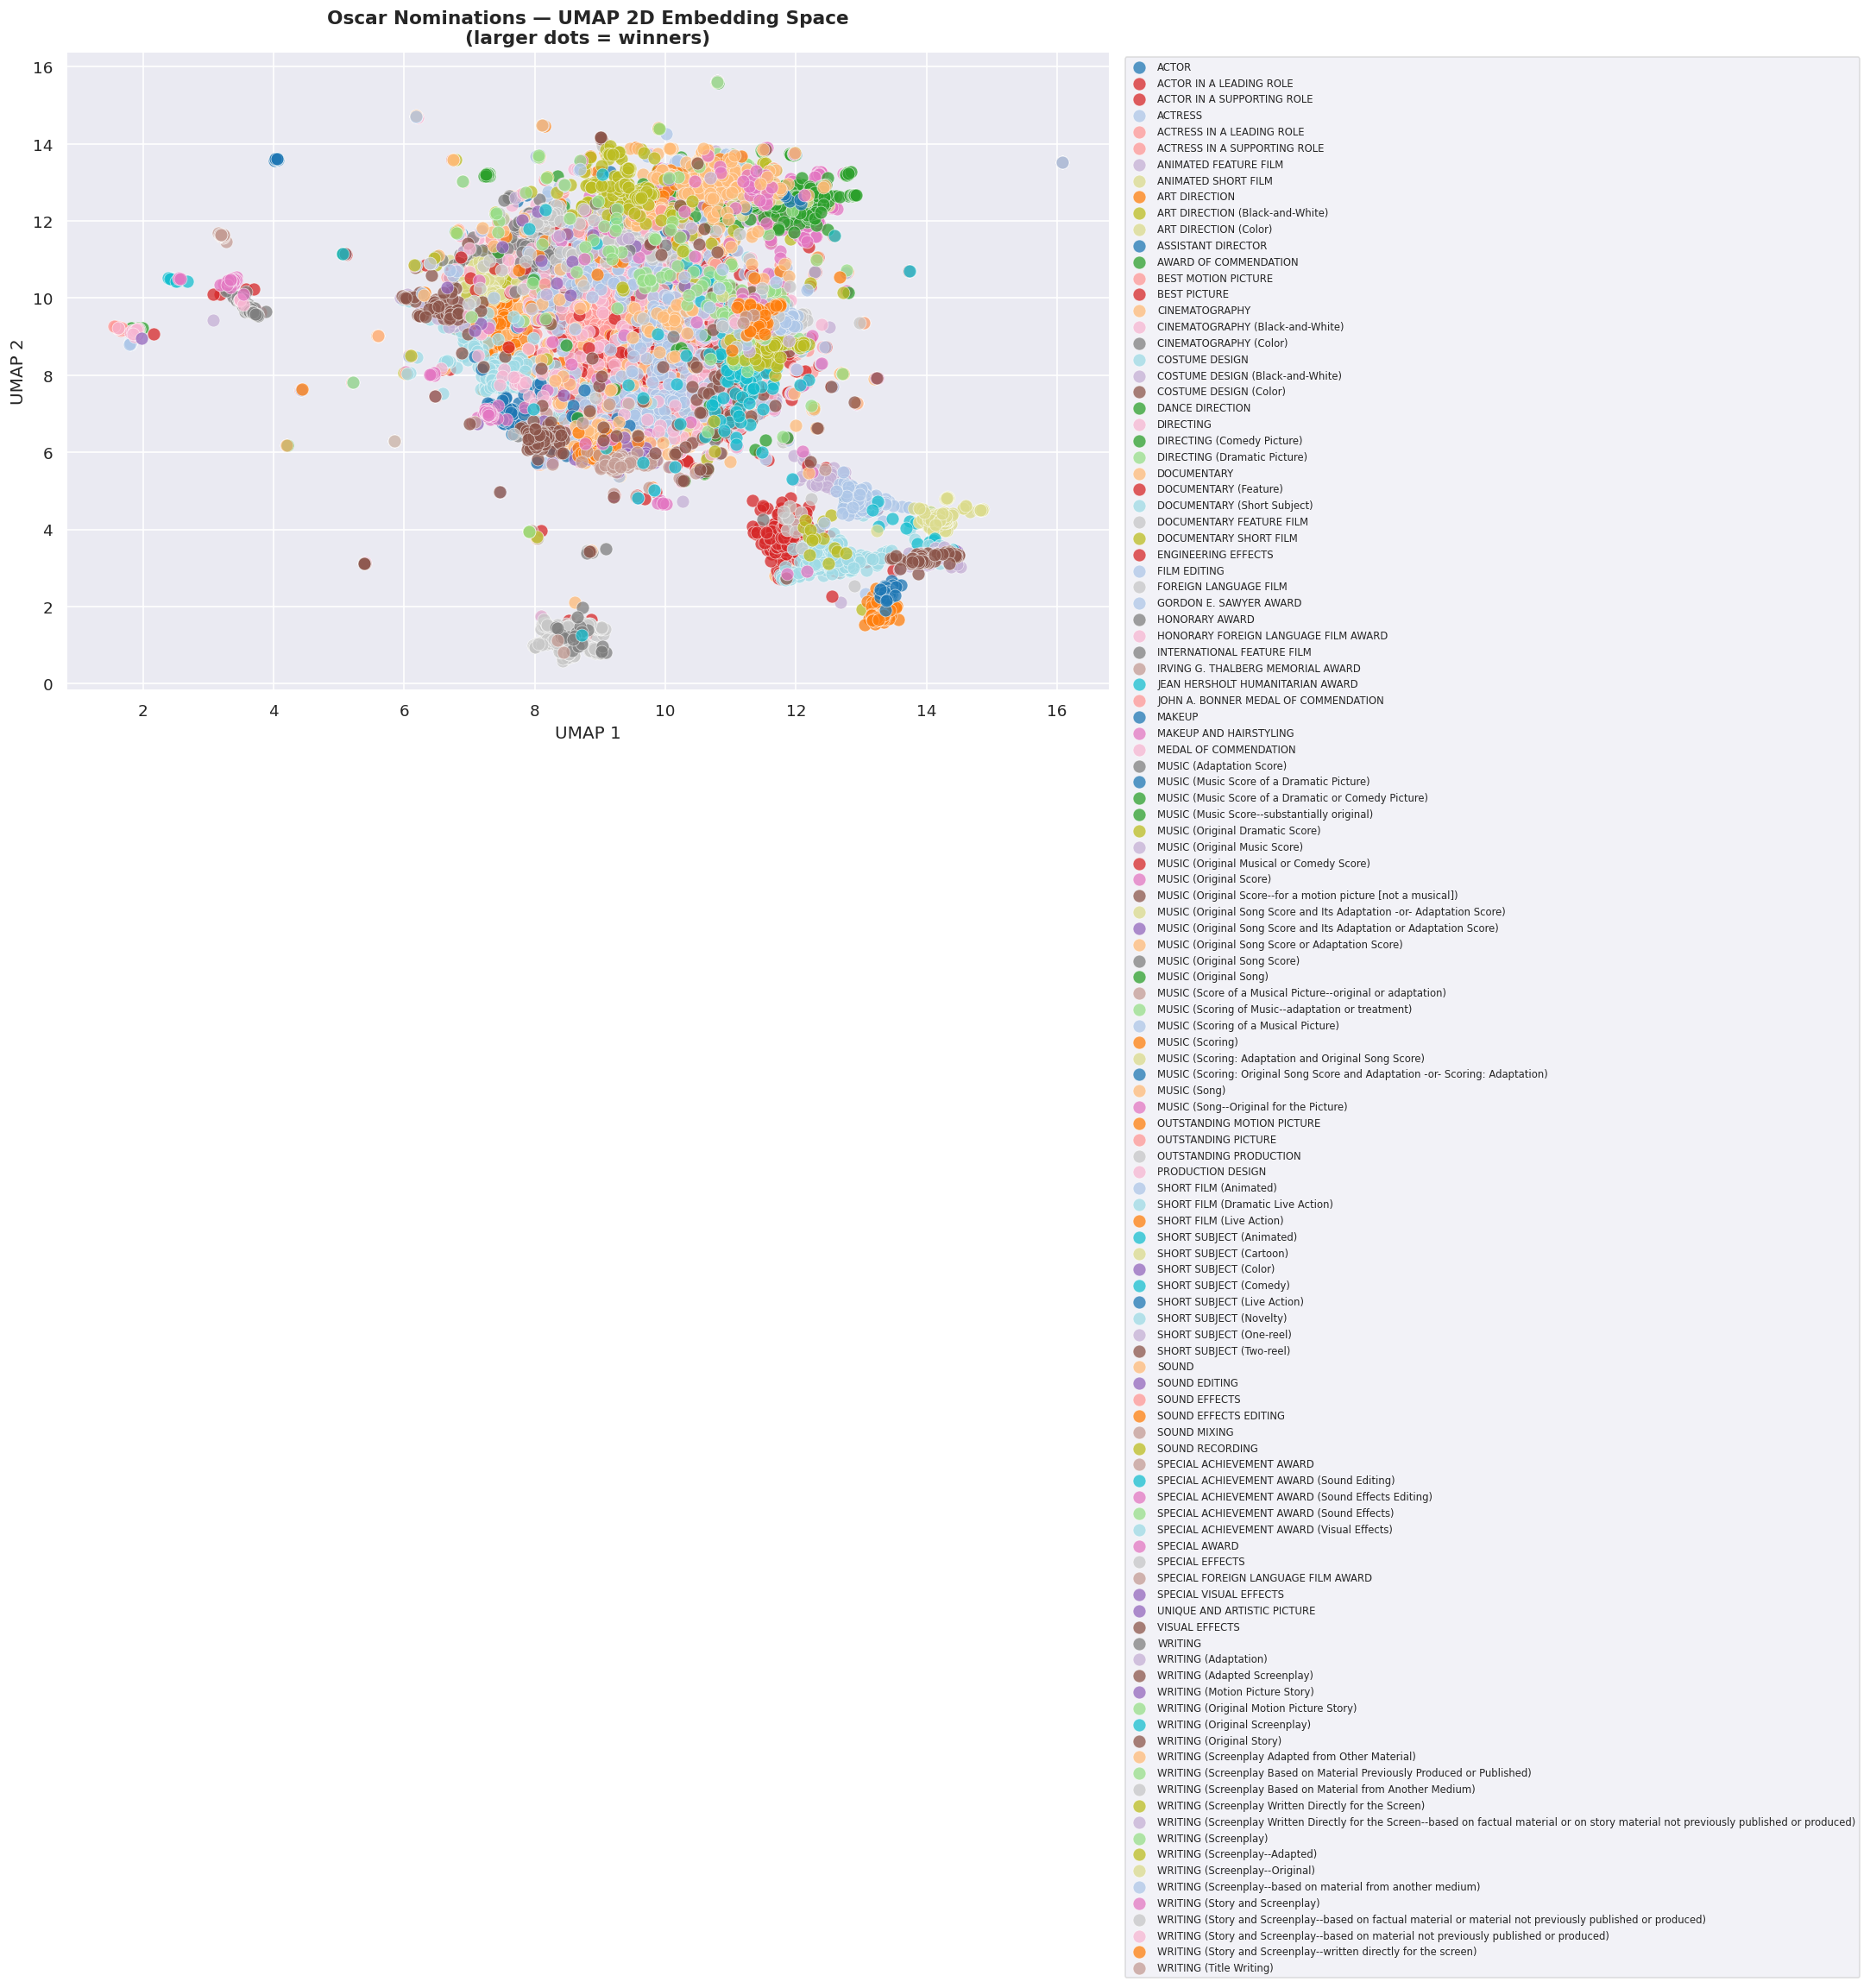

In [26]:
# ── Dimensionality reduction: UMAP preferred, PCA fallback ───────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    method = 'UMAP'
except ImportError:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2, random_state=42)
    method = 'PCA'

print(f'Using {method} for 2D projection...')
coords_2d = reducer.fit_transform(embeddings)
print(f'✅ 2D projection complete. Shape: {coords_2d.shape}')

df_plot = df.copy()
df_plot['x'] = coords_2d[:, 0]
df_plot['y'] = coords_2d[:, 1]

# Map categories to colors
categories = df_plot['category'].unique()
palette = dict(zip(categories, sns.color_palette('tab20', len(categories))))

fig, ax = plt.subplots(figsize=(13, 8))
for cat, grp in df_plot.groupby('category'):
    ax.scatter(grp['x'], grp['y'],
               c=[palette[cat]], label=cat,
               s=80 if grp['winner'].any() else 40,
               alpha=0.75, edgecolors='white', linewidths=0.4)

ax.set_title(f'Oscar Nominations — {method} 2D Embedding Space\n(larger dots = winners)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'{method} 1')
ax.set_ylabel(f'{method} 2')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, framealpha=0.6)
plt.tight_layout()
plt.show()

---
## 🏆 Step 8 — Advanced Analytics

Which categories have the highest intra-category semantic cohesion?

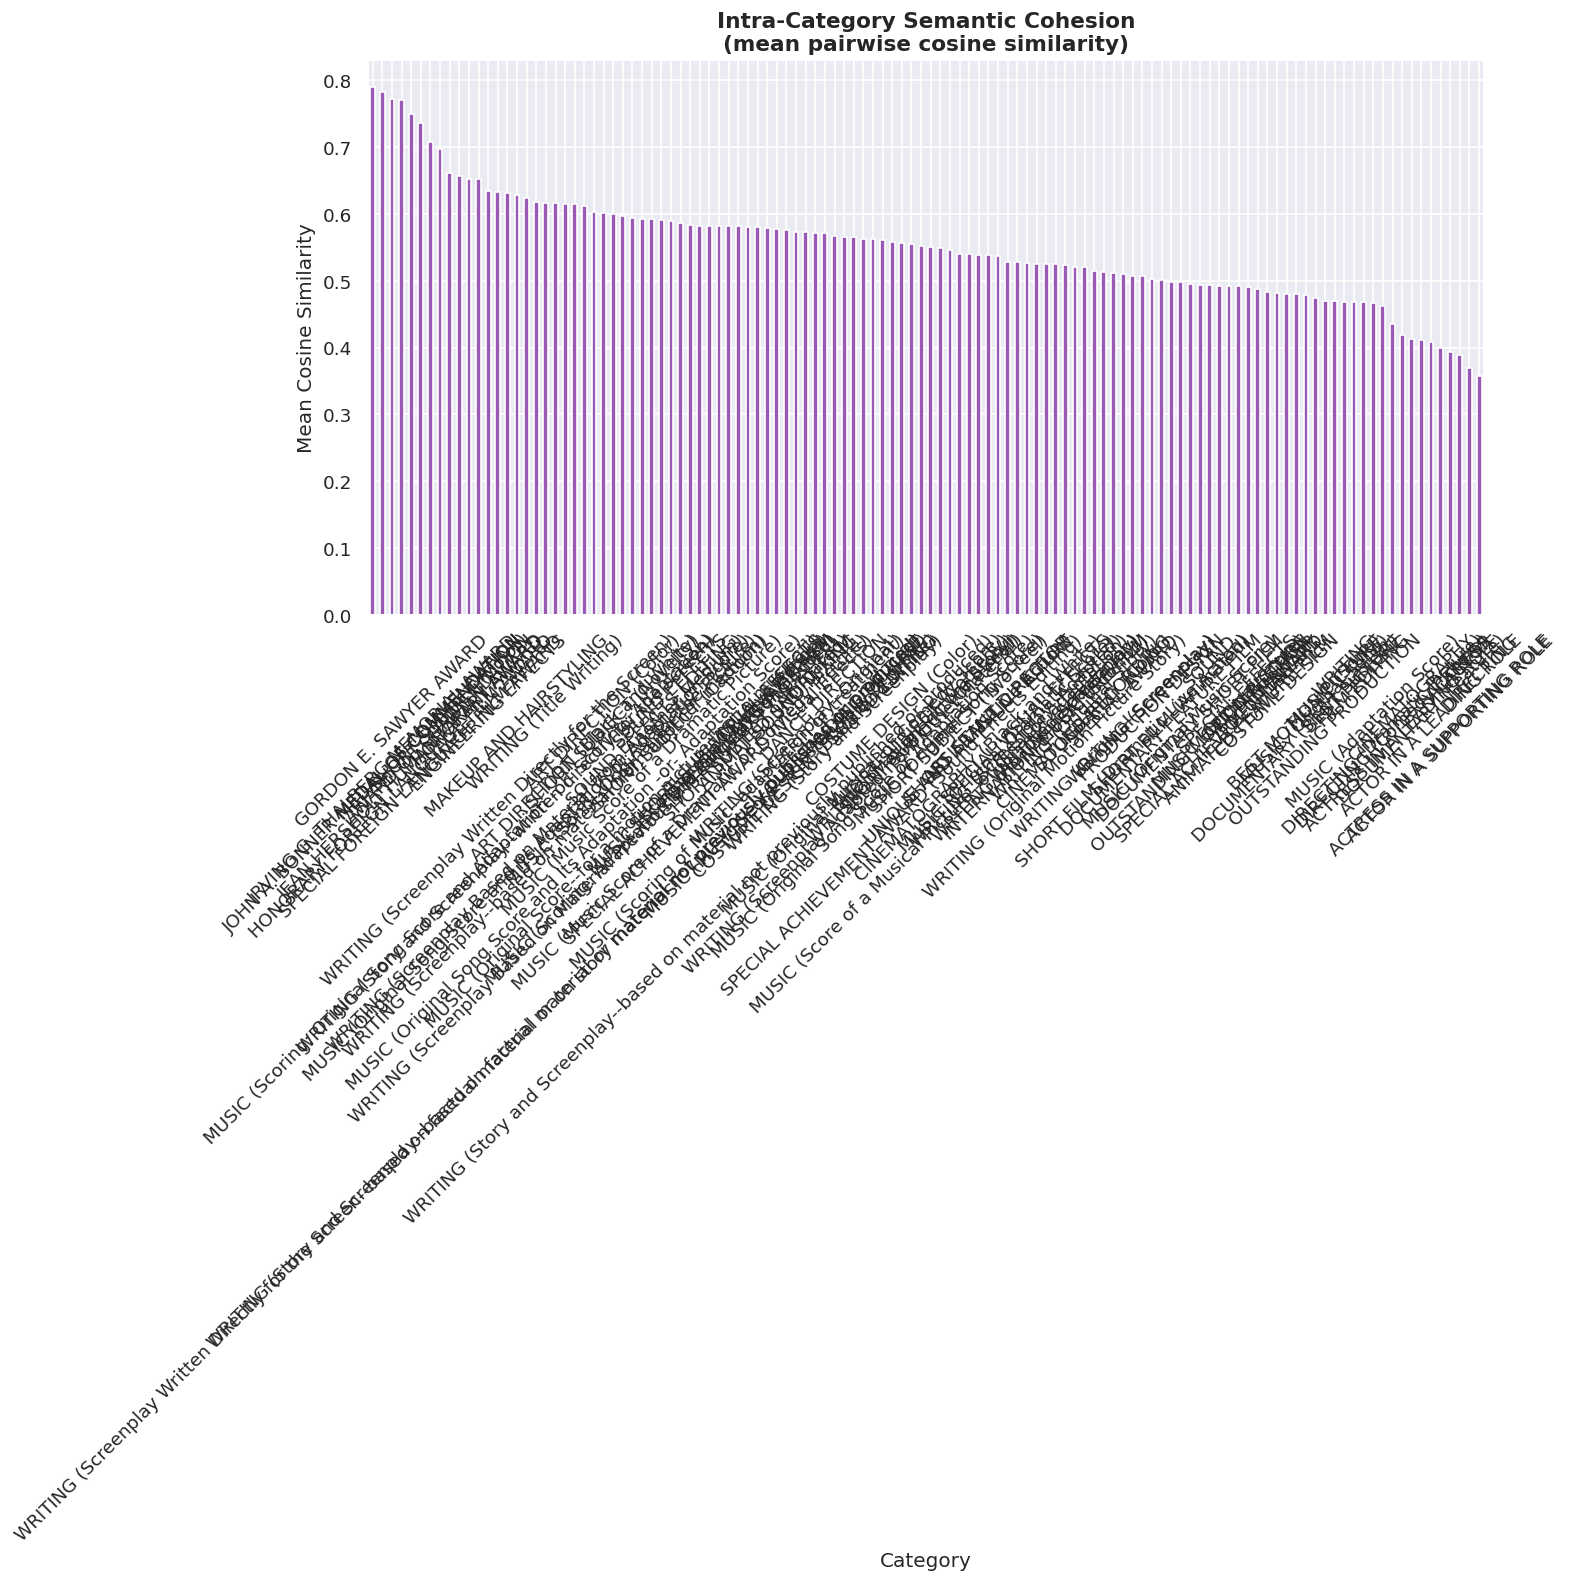

,cohesion_score
JOHN A. BONNER MEDAL OF COMMENDATION,0.790602
IRVING G. THALBERG MEMORIAL AWARD,0.782902
GORDON E. SAWYER AWARD,0.771742
HONORARY FOREIGN LANGUAGE FILM AWARD,0.770641
JEAN HERSHOLT HUMANITARIAN AWARD,0.750214
...,...
ACTRESS IN A SUPPORTING ROLE,0.399606
ACTOR IN A SUPPORTING ROLE,0.393601
ACTRESS,0.388722
ACTOR,0.368753


In [27]:
# ── Category cohesion: mean pairwise cosine similarity within each category ───
from sklearn.metrics.pairwise import cosine_similarity

cohesion = {}
for cat, grp in df.groupby('category'):
    idx = grp.index.tolist()
    if len(idx) < 2:
        continue
    emb_sub = embeddings[idx]
    sim_matrix = cosine_similarity(emb_sub)
    # Average upper-triangle (exclude diagonal)
    n = len(idx)
    upper = sim_matrix[np.triu_indices(n, k=1)]
    cohesion[cat] = float(np.mean(upper))

cohesion_df = pd.Series(cohesion).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
cohesion_df.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Intra-Category Semantic Cohesion\n(mean pairwise cosine similarity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Cosine Similarity')
ax.set_xlabel('Category')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(cohesion_df.rename('cohesion_score').to_frame())

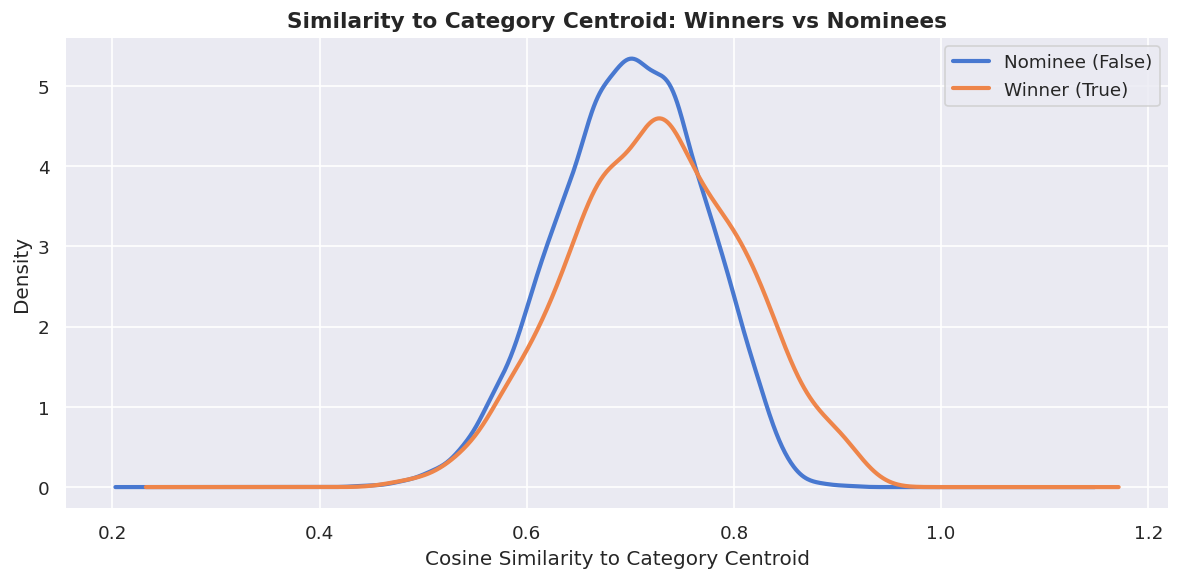

         count    mean     std     min     25%     50%     75%     max
winner                                                                
False   8538.0  0.6979  0.0704  0.4393  0.6502  0.7006  0.7483  0.9120
True    2570.0  0.7244  0.0845  0.4671  0.6659  0.7255  0.7842  0.9366


In [28]:
# ── Winner vs Nominee similarity to category centroid ─────────────────────────
centroid_results = []
for cat, grp in df.groupby('category'):
    idx = grp.index.tolist()
    if len(idx) < 2:
        continue
    emb_sub = embeddings[idx]
    centroid = emb_sub.mean(axis=0, keepdims=True)
    sims = cosine_similarity(emb_sub, centroid).flatten()
    for i, (_, row) in enumerate(grp.iterrows()):
        centroid_results.append({'category': cat, 'winner': row['winner'], 'sim_to_centroid': sims[i]})

cdf = pd.DataFrame(centroid_results)

fig, ax = plt.subplots(figsize=(10, 5))
cdf.groupby('winner')['sim_to_centroid'].plot(kind='density', ax=ax, linewidth=2.5)
ax.set_title('Similarity to Category Centroid: Winners vs Nominees', fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity to Category Centroid')
ax.legend(['Nominee (False)', 'Winner (True)'])
plt.tight_layout()
plt.show()

print(cdf.groupby('winner')['sim_to_centroid'].describe().round(4))

---
## 💾 Step 9 — Persist & Reload ChromaDB

ChromaDB is already persisted to disk at `CHROMA_DB_PATH`. The cell below shows how to reload it in a fresh session.

In [29]:
# ── Reload from disk (demo) ───────────────────────────────────────────────────
client2 = chromadb.PersistentClient(path=CHROMA_DB_PATH)
collection2 = client2.get_collection(name=COLLECTION_NAME)
print(f'✅ Reloaded collection from disk: {collection2.count()} documents')

# Quick query on reloaded collection
test_emb = model.encode(['best foreign language drama'], normalize_embeddings=True).tolist()
res = collection2.query(query_embeddings=test_emb, n_results=3, include=['metadatas', 'distances'])
for m, d in zip(res['metadatas'][0], res['distances'][0]):
    print(f'  {round(1-d, 3):.3f}  →  {m["name"]} | {m["film"]} | {m["category"]} ({m["year_ceremony"]})')

✅ Reloaded collection from disk: 11110 documents
  0.493  →  Germany | The Lives of Others | FOREIGN LANGUAGE FILM (2007)
  0.473  →  Argentina | Wild Tales | FOREIGN LANGUAGE FILM (2015)
  0.468  →  France | A Simple Story | FOREIGN LANGUAGE FILM (1980)


---
## ✅ Summary

| Step | What happened |
|------|---------------|
| 1 | Loaded Oscar nominations from Kaggle CSV or built-in sample |
| 2 | EDA: category counts, yearly trends, top-nominated films |
| 3 | Built rich text documents and embedded with `sentence-transformers` |
| 4 | Stored embeddings + metadata in persistent **ChromaDB** |
| 5 | Ran semantic queries with optional year / category / winner filters |
| 6 | Visualised cosine similarity scores |
| 7 | Projected embeddings to 2D with UMAP/PCA |
| 8 | Measured intra-category semantic cohesion; compared winner vs nominee distance to centroid |
| 9 | Demonstrated persisting & reloading ChromaDB from disk |

### 🚀 Next Steps
- Swap in the full Kaggle dataset (1927–2023) for richer analysis
- Try `all-mpnet-base-v2` for higher-quality embeddings
- Add a Gradio UI for interactive semantic search
- Train a classifier on embeddings to predict Oscar winners